#Desarrollo


##Preparación del entorno


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_excel("/content/Registros_Venta.xlsx", sheet_name="Fact_Ventas")

##Exploración inicial

In [ ]:
print("Las dimensiones de la matriz son:", df.shape[0], "filas, por", df.shape[1], "columnas.")


Las dimensiones de la matriz son: 1004 filas, por 13 columnas.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Venta         1004 non-null   object 
 1   Fecha            1004 non-null   object 
 2   Cliente          1003 non-null   object 
 3   Tipo_Cliente     1004 non-null   object 
 4   Region           1004 non-null   object 
 5   Vendedor         1004 non-null   object 
 6   Canal_Venta      1004 non-null   object 
 7   Producto         1004 non-null   object 
 8   Categoria        1004 non-null   object 
 9   Cantidad         1004 non-null   int64  
 10  Precio_Unitario  1003 non-null   float64
 11  Costo_Unitario   1004 non-null   int64  
 12  Descuento_Pct    1004 non-null   float64
dtypes: float64(2), int64(2), object(9)
memory usage: 102.1+ KB


Observaciones:
* Las columnas `ID_Venta`, `Fecha`, `Cliente`, `Tipo_Cliente`, `Region`, `Vendedor`, `Canal_Venta`, `Producto` y `Categoría` son categóricas.
* La columna `Fecha` debería ser tipo 'datetime' debido a su formato.
* Las columnas `Cantidad` y `Costo_Unitaio` son numéicas enteras.
* Las columnas `Precio_Unitario` y `Descuento_Pct` son numéicas de punto flotante.

##Análisis principal

###Valores nulos

In [ ]:
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
ID_Venta           0
Fecha              0
Cliente            1
Tipo_Cliente       0
Region             0
Vendedor           0
Canal_Venta        0
Producto           0
Categoria          0
Cantidad           0
Precio_Unitario    1
Costo_Unitario     0
Descuento_Pct      0
dtype: int64


Se encuentran 2 registros con valores nulos. Siendo tan pocos, se eliminan ya que su ausencia no influirá en los resultados finales.

In [ ]:
df.dropna(inplace=True)
print(df.isnull().sum())

ID_Venta           0
Fecha              0
Cliente            0
Tipo_Cliente       0
Region             0
Vendedor           0
Canal_Venta        0
Producto           0
Categoria          0
Cantidad           0
Precio_Unitario    0
Costo_Unitario     0
Descuento_Pct      0
dtype: int64


###Registros duplicados

In [ ]:
for col in df.columns:
  print("Valores únicos en", col, ":", df[col].nunique())

Valores únicos en ID_Venta : 1001
Valores únicos en Fecha : 661
Valores únicos en Cliente : 50
Valores únicos en Tipo_Cliente : 4
Valores únicos en Region : 6
Valores únicos en Vendedor : 8
Valores únicos en Canal_Venta : 5
Valores únicos en Producto : 30
Valores únicos en Categoria : 8
Valores únicos en Cantidad : 11
Valores únicos en Precio_Unitario : 27
Valores únicos en Costo_Unitario : 26
Valores únicos en Descuento_Pct : 733


Se observa que en `ID_Venta` existen 1003 registros únicos, pero existen 1004 registros en total, por ende debe existir un duplicado como mínimo.

In [ ]:
duplicates = df[df.duplicated(keep=False)]
print(duplicates)

     ID_Venta       Fecha            Cliente Tipo_Cliente  Region  \
0      V00001  2026-01-28  Distribuidora Sol  Corporativo  Centro   
1003   V00001  2026-01-28  Distribuidora Sol  Corporativo  Centro   

           Vendedor Canal_Venta            Producto  Categoria  Cantidad  \
0     Daniela López    WhatsApp  Monitor Samsung 24  Monitores         1   
1003  Daniela López    WhatsApp  Monitor Samsung 24  Monitores         1   

      Precio_Unitario  Costo_Unitario  Descuento_Pct  
0              5200.0            3900          12.63  
1003           5200.0            3900          12.63  


Se encuentran 2 registos duplicados, por lo que se eliminará el segundo.

In [ ]:
df = df.drop_duplicates()

###Inconsistencias de texto

In [ ]:
unicos = df[['Cliente', 'Tipo_Cliente', 'Region', 'Vendedor', 'Canal_Venta', 'Producto', 'Categoria']]

for col in unicos:
  print(col, ":", sorted(df[col].unique()),"\n")

Cliente : ['Comercial Centro', 'Comercial Express', 'Comercial Futuro', 'Comercial Integra', 'Comercial Las Américas', 'Comercial López', 'Comercial Moderna', 'Comercial Premier', 'Comercial Rivera', 'Corporación Atlas', 'Corporación Delta', 'Corporación Digital', 'Corporación Innovar', 'Corporación Premium', 'Distribuciones Atlas', 'Distribuciones Globales', 'Distribuciones Luna', 'Distribuidora Nacional', 'Distribuidora Sol', 'Empresa Alfa', 'Empresa Beta', 'Empresa Dinámica', 'Empresa Horizonte', 'Empresa Nexus', 'Empresa Omega', 'Grupo Comercial Centroamericano', 'Grupo Elite', 'Grupo Empresarial Maya', 'Grupo Horizonte', 'Grupo Innovación', 'Grupo Progreso', 'Grupo Sigma', 'Grupo Tecnológico', 'Grupo Vanguard', 'Grupo Visionario', 'Importadora Maya', 'Importadora del Norte', 'Industrias Unidas', 'Inversiones Morales', 'Inversiones del Sur', 'Negocios Estratégicos', 'Negocios Unidos', 'Servicios Corporativos', 'Servicios Ejecutivos', 'Servicios Globales', 'Soluciones Digitales', 'S

No se encuentran inconsistencias sintácticos o semánticos en las columnas categóricas.  

###Errores de formato

Convertimos la columna `Fecha` al tipo 'datetime' en el formato 'yyyy-mm-dd'.

In [ ]:
df['Fecha'] = pd.to_datetime(df['Fecha']).dt.strftime('%Y-%m-%d')

No se detectan otros posibles errores de formato.

###Datos atípicos

In [ ]:
cuantitativos = df[['Cantidad', 'Costo_Unitario', 'Precio_Unitario', 'Descuento_Pct']]
cuantitativos.describe()

,Cantidad,Costo_Unitario,Precio_Unitario,Descuento_Pct
count,1001.000000,1001.000000,1001.000000,1001.000000
mean,5.377622,5393.196803,6814.535465,7.299131
std,2.855391,5348.003774,6480.026312,4.270087
min,-2.000000,280.000000,450.000000,0.000000
25%,3.000000,1200.000000,1800.000000,3.620000
50%,5.000000,3900.000000,5200.000000,7.220000
75%,8.000000,6900.000000,8700.000000,10.840000
max,10.000000,20000.000000,24500.000000,14.980000


###Semánticamente incorrectos

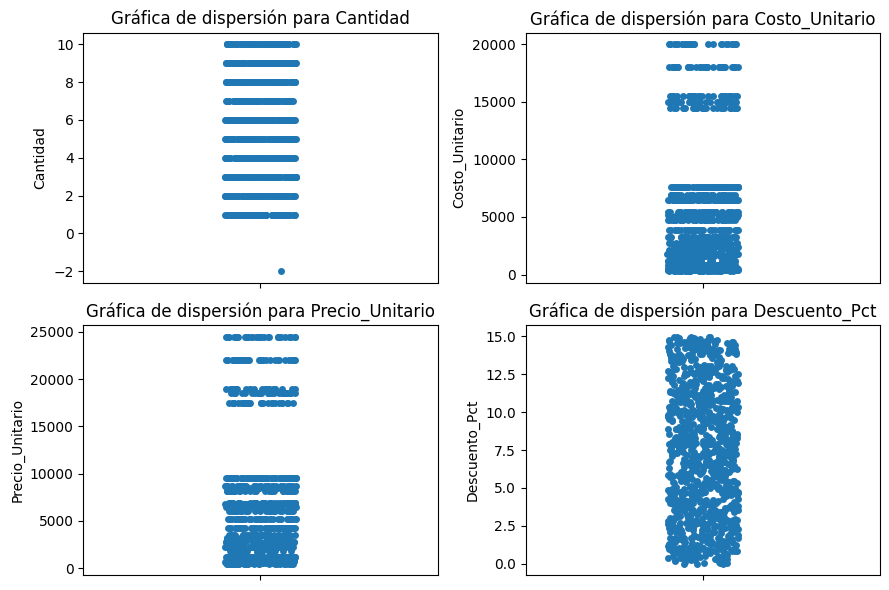

In [ ]:
plt.figure(figsize=(9,6))

for i, columna in enumerate(cuantitativos):
  plt.subplot(2, 2, i+1)
  sns.stripplot(y=cuantitativos[columna])
  plt.ylabel(columna)
  plt.title(f"Gráfica de dispersión para {columna}")

plt.tight_layout()
plt.show()

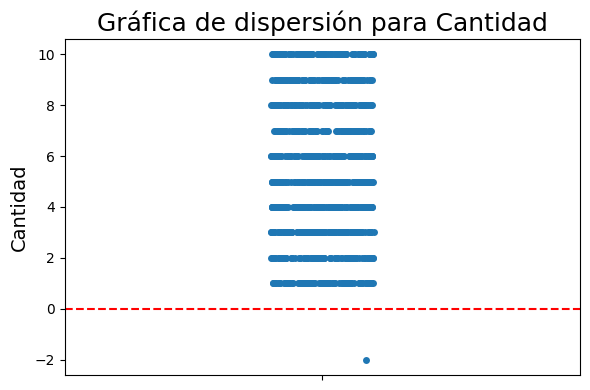

In [ ]:
plt.figure(figsize=(6,4))

columna = 'Cantidad'
sns.stripplot(y=cuantitativos[columna])
plt.ylabel(columna, fontsize=14)
plt.title(f"Gráfica de dispersión para {columna}", fontsize=18)
plt.axhline(y=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

La tabla de información de los valores cuantitativos y el gráfico de dispersiónde cantidad confirman un valor atípico de -2.

In [ ]:
df = df[df['Cantidad'] >= 0]

###Estadísticamente atípicos

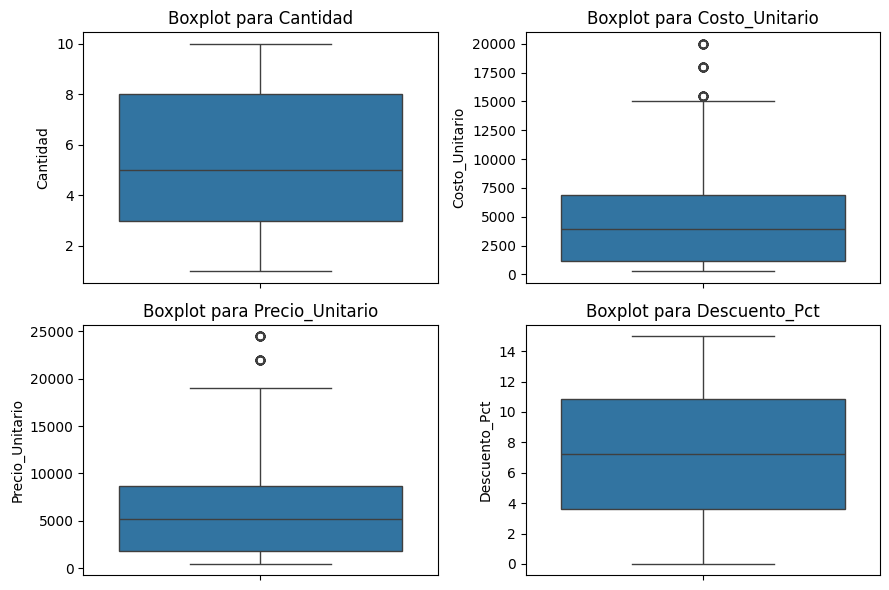

In [ ]:
plt.figure(figsize=(9,6))

for i, columna in enumerate(cuantitativos):
  plt.subplot(2, 2, i+1)
  sns.boxplot(y=df[columna])
  plt.title(f"Boxplot para {columna}")

plt.tight_layout()
plt.show()

Los diagramas de cajas y bigotes muestran la existencia de valores atípicos en las categorías `Costo_Unitario` y `Precio_Unitario`.

In [ ]:
def contarAtipicos_iqr(series):
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)
  IQR = Q3 - Q1

  lowerBound = Q1 - 1.5 * IQR
  upperBound = Q3 + 1.5 * IQR
  outliers = series[(series < lowerBound) | (series > upperBound)]
  return len(outliers)

Se define una función que cuenta valores a 1.5 veces el rango intercuartílico desde el primer y tercer cuartil. Se aplica esta función a los datos.

In [ ]:
for i, columna in enumerate(df[['Precio_Unitario', 'Costo_Unitario']]):
    cantidadAtipicosColumna = contarAtipicos_iqr(df[columna])
    print(f"Número de valores atípicos en la columna {columna}: {cantidadAtipicosColumna}")

Número de valores atípicos en la columna Precio_Unitario: 64
Número de valores atípicos en la columna Costo_Unitario: 92


Se define una función que elimina valores atípicos. Se aplica esta función a los datos.

In [ ]:
def quitarAtipicos_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lowerBound = Q1 - 1.5 * IQR
    upperBound = Q3 + 1.5 * IQR

    return series[(series >= lowerBound) & (series <= upperBound)]

In [ ]:
sizeBefore = df.shape[0]

for i, columna in enumerate(df[['Precio_Unitario', 'Costo_Unitario']]):
    df = df[df.index.isin(quitarAtipicos_iqr(df[columna]).index)]

sizeAfter = df.shape[0]
total = sizeBefore - sizeAfter
pct = (1- (sizeAfter/sizeBefore))*100

print(f"Se eliminaron {total} registros ({pct:.2f}%).")

Se eliminaron 151 registros (15.10%).


##Exportación

Una vez realizada la limpieza se exportan los datos para análisis futuro.

In [ ]:
#Se exportan los datos limpios a un achivo csv
df.to_csv('Registros_Venta_Limpios.csv', index=False)

In [ ]:
df.columns

Index(['ID_Venta', 'Fecha', 'Cliente', 'Tipo_Cliente', 'Region', 'Vendedor',
       'Canal_Venta', 'Producto', 'Categoria', 'Cantidad', 'Precio_Unitario',
       'Costo_Unitario', 'Descuento_Pct'],
      dtype='object')

#Análisis avanzado

##Segmentación de clientes

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [ ]:
df["Venta"] = df["Cantidad"] * df["Precio_Unitario"] * (1 - df["Descuento_Pct"] / 100)

In [ ]:
clientes = (
    df.groupby("Cliente")
      .agg(
          Total_Comprado=("Venta", "sum"),
          Numero_Compras=("ID_Venta", "nunique"),
          Ticket_Promedio=("Venta", "mean")
      )
      .reset_index()
)

clientes.head()

,Cliente,Total_Comprado,Numero_Compras,Ticket_Promedio
0,Comercial Centro,293724.940,13,22594.226154
1,Comercial Express,370191.540,17,21775.972941
2,Comercial Futuro,399214.460,18,22178.581111
3,Comercial Integra,390309.875,18,21683.881944
4,Comercial Las Américas,250773.880,19,13198.625263


In [ ]:
X = clientes[
    [
        "Total_Comprado",
        "Numero_Compras",
        "Ticket_Promedio"
    ]
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

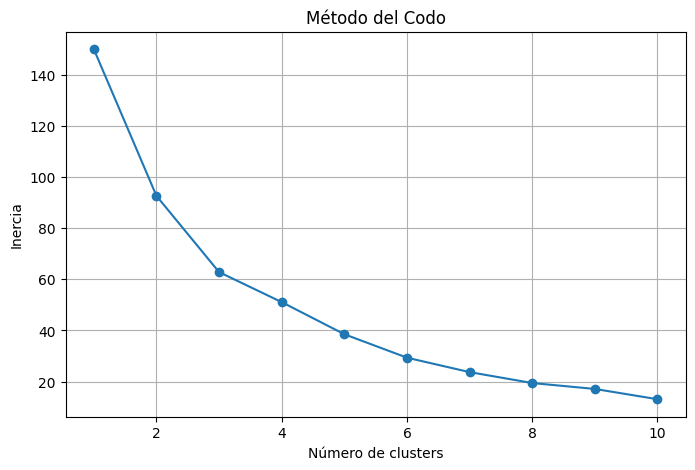

In [ ]:
inercias = []

for k in range(1,11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inercias.append(modelo.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inercias, marker="o")

plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")

plt.grid(True)

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clientes["Cluster"] = kmeans.fit_predict(X_scaled)
centros_escalados = kmeans.cluster_centers_
centros = scaler.inverse_transform(centros_escalados)

In [ ]:
clientes.sort_values("Cluster").head(5)

,Cliente,Total_Comprado,Numero_Compras,Ticket_Promedio,Cluster
1,Comercial Express,370191.540,17,21775.972941,0
2,Comercial Futuro,399214.460,18,22178.581111,0
3,Comercial Integra,390309.875,18,21683.881944,0
7,Comercial Premier,485354.470,20,24267.723500,0
6,Comercial Moderna,410253.850,15,27350.256667,0


In [ ]:
resumen = (
    clientes
    .groupby("Cluster")
    .agg(
        Clientes=("Cliente","count"),
        Gasto_Promedio=("Total_Comprado","mean"),
        Compras_Promedio=("Numero_Compras","mean"),
        Ticket_Promedio=("Ticket_Promedio","mean")
    )
)

print(resumen.round(2))

         Clientes  Gasto_Promedio  Compras_Promedio  Ticket_Promedio
Cluster                                                             
0              19       423177.21             16.47         26160.65
1              20       265071.84             14.05         19008.50
2              11       448159.58             23.18         19289.71


In [ ]:
mapa = {
    0: "Frecuencia Media - Alto Gasto",
    1: "Baja Frecuencia - Bajo Gasto",
    2: "Alta Frecuencia - Alto Gasto"
}

clientes["Segmento"] = clientes["Cluster"].map(mapa)

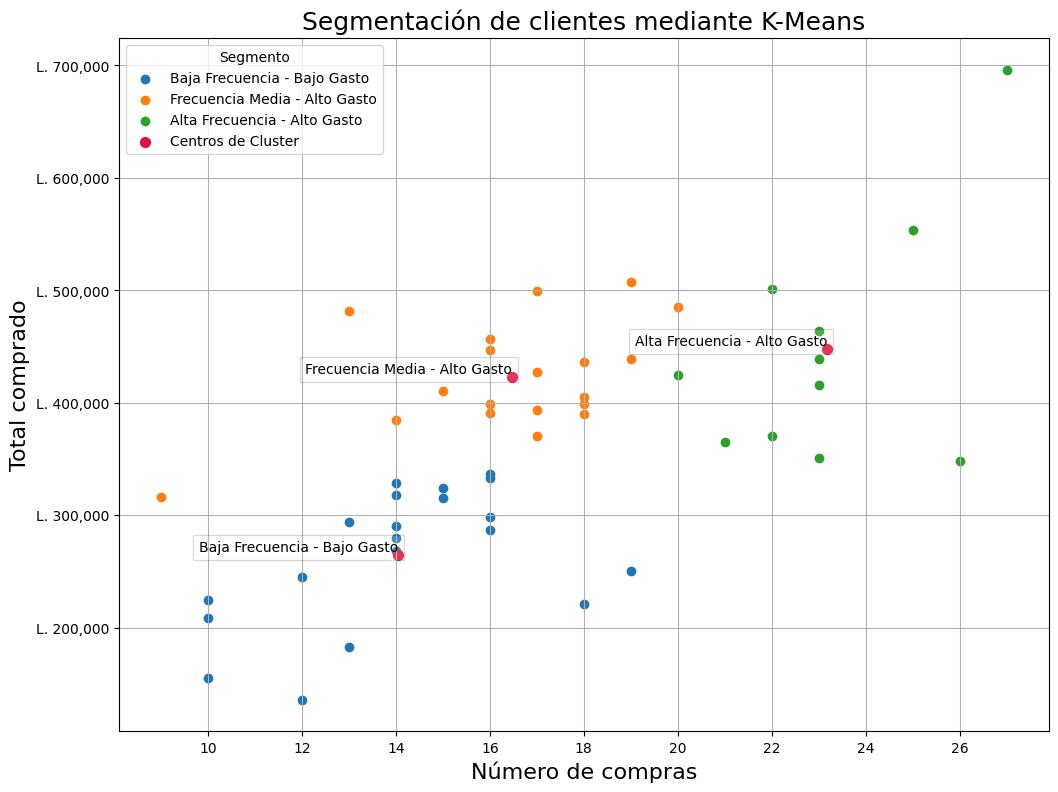

In [ ]:
plt.figure(figsize=(12,9))

for segmento in clientes["Segmento"].unique():

    datos = clientes[clientes["Segmento"] == segmento]

    plt.scatter(
        datos["Numero_Compras"],
        datos["Total_Comprado"],
        label=segmento
    )

plt.xlabel("Número de compras", fontsize=16)
plt.ylabel("Total comprado", fontsize=16)
plt.title("Segmentación de clientes mediante K-Means", fontsize=18)
plt.scatter(centros[:, 1], centros[:, 0], marker='.', s=200, color='crimson', label='Centros de Cluster')
plt.legend(title="Segmento")

for i, centro in enumerate(centros):
    plt.text(
        centro[1],      # Número de compras
        centro[0],      # Total comprado
        mapa[i],
        fontsize=10,
        ha="right",
        va = "bottom",
        bbox=dict(facecolor="white", alpha=0.15)
    )

plt.grid(True)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('L. {x:,.0f}'))

plt.show()

##Análisis ABC de productos

In [ ]:
df.columns

Index(['ID_Venta', 'Fecha', 'Cliente', 'Tipo_Cliente', 'Region', 'Vendedor',
       'Canal_Venta', 'Producto', 'Categoria', 'Cantidad', 'Precio_Unitario',
       'Costo_Unitario', 'Descuento_Pct', 'Venta'],
      dtype='object')

In [ ]:
# 1. Ordenar de mayor a menor
df = df.sort_values('Venta', ascending=False)

# 2. Calcular porcentaje acumulado
df['Ventas_Acum'] = df['Venta'].cumsum()
df['Pct_Acum'] = df['Ventas_Acum'] / df['Venta'].sum() * 100

# 3. Asignar categoría
def clasificar(pct):
    if pct <= 80:
        return 'A'
    elif pct <= 95:
        return 'B'
    else:
        return 'C'

df['Categoria_ABC'] = df['Pct_Acum'].apply(clasificar)

In [ ]:
df.columns

Index(['ID_Venta', 'Fecha', 'Cliente', 'Tipo_Cliente', 'Region', 'Vendedor',
       'Canal_Venta', 'Producto', 'Categoria', 'Cantidad', 'Precio_Unitario',
       'Costo_Unitario', 'Descuento_Pct', 'Venta', 'Ventas_Acum', 'Pct_Acum',
       'Categoria_ABC'],
      dtype='object')

In [ ]:
print([c for c in df.columns if 'enta' in c.lower() or 'total' in c.lower() or 'bruta' in c.lower()])

['ID_Venta', 'Canal_Venta', 'Venta', 'Ventas_Acum']


In [ ]:
df2 = df
df = df.groupby('Producto')['Venta'].sum().reset_index()
df = df.sort_values('Venta', ascending=False)

# Luego recalcula el ABC
df['Venta_Acum'] = df['Venta'].cumsum()
df['Pct_Acum'] = df['Venta_Acum'] / df['Venta'].sum() * 100
df['Categoria_ABC'] = df['Pct_Acum'].apply(clasificar)

In [ ]:
df = df.reset_index(drop=True)

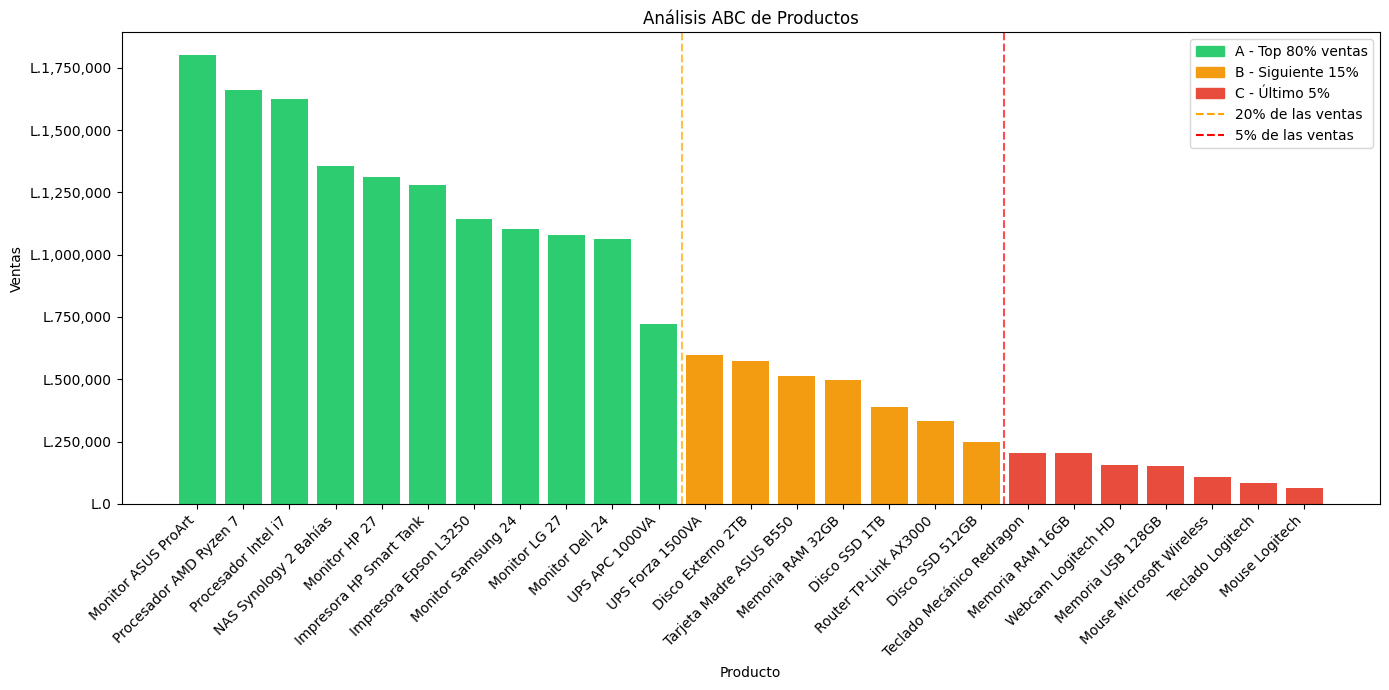

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))

for i, (_, row) in enumerate(df.iterrows()):
    color = {'A': '#2ecc71', 'B': '#f39c12', 'C': '#e74c3c'}[row['Categoria_ABC']]
    ax1.bar(i, row['Venta'], color=color)

ax1.set_xlabel('Producto')
ax1.set_ylabel('Ventas')
ax1.set_xticks(range(len(df)))
ax1.set_xticklabels(df['Producto'], rotation=45, ha='right')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'L.{x:,.0f}'))

# Encontrar índices donde cambia la categoría
cambio_ab = df[df['Categoria_ABC'] == 'B'].index[0] - 0.5
cambio_bc = df[df['Categoria_ABC'] == 'C'].index[0] - 0.5

ax1.axvline(x=cambio_ab, color='orange', linestyle='--', alpha=0.7)
ax1.axvline(x=cambio_bc, color='red', linestyle='--', alpha=0.7)

from matplotlib.patches import Patch
leyenda = [Patch(color='#2ecc71', label='A - Top 80% ventas'),
           Patch(color='#f39c12', label='B - Siguiente 15%'),
           Patch(color='#e74c3c', label='C - Último 5%'),
           plt.Line2D([0], [0], color='orange', linestyle='--', label='20% de las ventas'),
           plt.Line2D([0], [0], color='red', linestyle='--', label='5% de las ventas')]
ax1.legend(handles=leyenda, loc='upper right')

plt.title('Análisis ABC de Productos')
plt.tight_layout()
plt.show()

##Análisis de tendencia

In [ ]:
df2.columns

Index(['ID_Venta', 'Fecha', 'Cliente', 'Tipo_Cliente', 'Region', 'Vendedor',
       'Canal_Venta', 'Producto', 'Categoria', 'Cantidad', 'Precio_Unitario',
       'Costo_Unitario', 'Descuento_Pct', 'Venta', 'Ventas_Acum', 'Pct_Acum',
       'Categoria_ABC'],
      dtype='object')

In [ ]:
df2['Año'] = pd.to_datetime(df2['Fecha']).dt.year
df2['Mes'] = pd.to_datetime(df2['Fecha']).dt.month

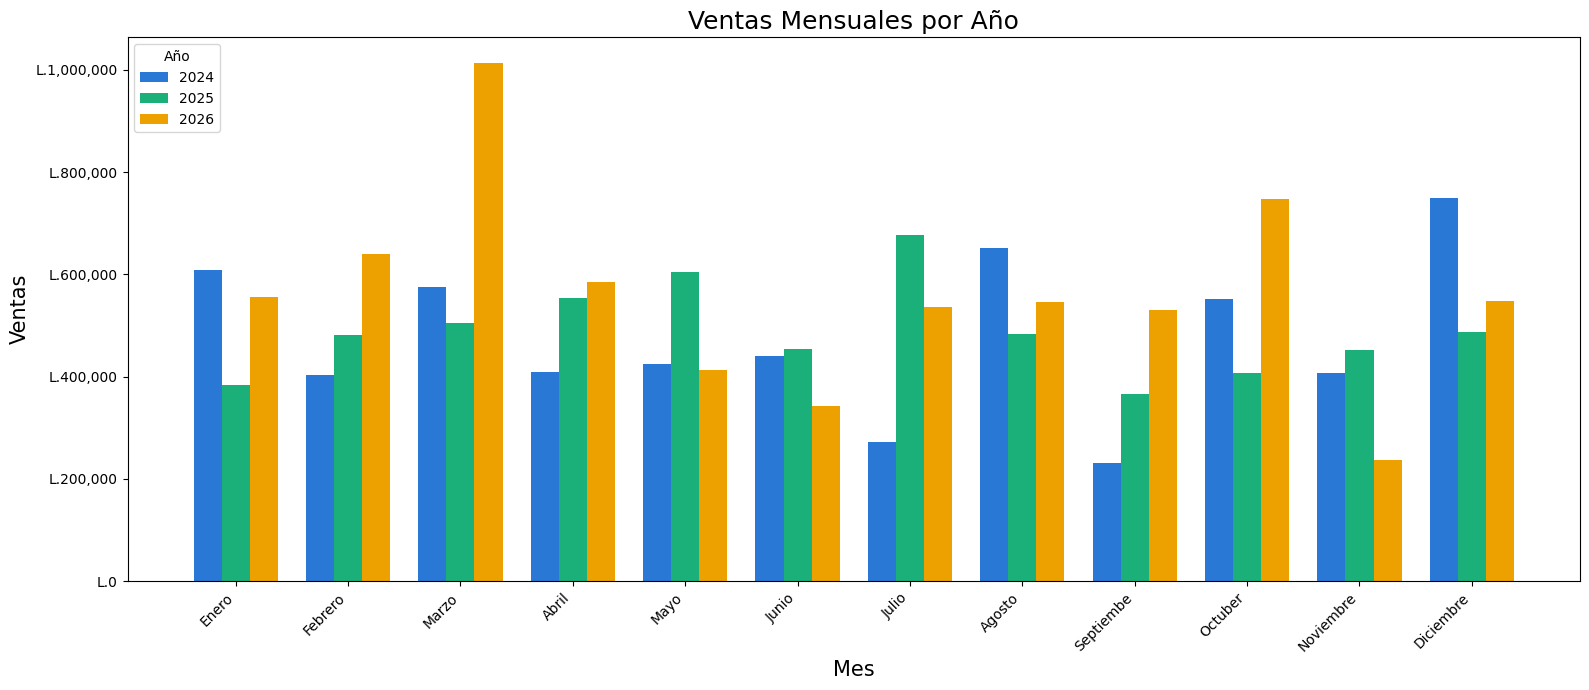

In [ ]:
df_mensual = df2.groupby(['Año', 'Mes'])['Venta'].sum().reset_index()

años = sorted(df_mensual['Año'].unique())
meses = list(range(1, 13))
nombres_meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio','Agosto','Septiembe','Octuber','Noviembre','Diciembre']

COLORS = {2024: '#2a78d6', 2025: '#1baf7a', 2026: '#eda100'}

x = np.arange(len(meses))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 7))

for i, año in enumerate(años):
    datos = []
    for mes in meses:
        fila = df_mensual[(df_mensual['Año'] == año) & (df_mensual['Mes'] == mes)]
        datos.append(fila['Venta'].values[0] if not fila.empty else 0)
    ax.bar(x + i * width, datos, width, label=str(año), color=COLORS.get(año, f'C{i}'))

ax.set_xlabel('Mes', fontsize=15)
ax.set_ylabel('Ventas', fontsize=15)
ax.set_title('Ventas Mensuales por Año', fontsize=18)
ax.set_xticks(x + width)
ax.set_xticklabels(nombres_meses, rotation=45, ha='right')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'L.{x:,.0f}'))
ax.legend(title='Año', loc='upper left')

plt.tight_layout()
plt.show()